In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

## **Modeling Setup**

In [2]:
df = pd.read_csv('data_cleaned.csv')
df['Log_Price'] = np.log(df['Price'])

cat_cols = ['Apartment type', 'Region', 'Renovation']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

display(df.head(), df.shape)

,Price,Metro station,Minutes to metro,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Log_Price,Apartment type_Secondary,Region_Moscow region,Renovation_Designer,Renovation_European-style renovation,Renovation_Without renovation
0,6300000.0,Опалиха,6.0,1.0,30.6,11.1,8.5,25.0,25,15.656060,1,1,0,0,0
1,9000000.0,Павшино,2.0,1.0,49.2,20.0,10.0,6.0,15,16.012735,1,1,0,1,0
2,11090000.0,Мякинино,14.0,1.0,44.7,16.2,13.1,10.0,25,16.221554,1,1,0,0,0
3,8300000.0,Строгино,8.0,1.0,35.1,16.0,11.0,12.0,33,15.931766,1,1,0,1,0
4,6450000.0,Опалиха,6.0,1.0,37.7,15.2,4.0,5.0,5,15.679591,1,1,0,0,1


(18374, 15)

In [12]:
X = df.drop(columns = ['Price', 'Log_Price', 'Metro station'])
y = df['Log_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set:  {X_train.shape}")
print(f"Test set:      {X_test.shape}")
print(f"Total features: {X_train.shape[1]}")
print(f"\nFeature names:\n{list(X.columns)}")

Training set:  (14699, 12)
Test set:      (3675, 12)
Total features: 12

Feature names:
['Minutes to metro', 'Number of rooms', 'Area', 'Living area', 'Kitchen area', 'Floor', 'Number of floors', 'Apartment type_Secondary', 'Region_Moscow region', 'Renovation_Designer', 'Renovation_European-style renovation', 'Renovation_Without renovation']


## **OLS Linear Regression (Baseline)**

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

ols = LinearRegression()
ols.fit(X_train, y_train)

y_pred_ols_train = ols.predict(X_train)
y_pred_ols_test = ols.predict(X_test)

# Metrics 
train_r2_score = r2_score(y_train, y_pred_ols_train)
test_r2_score = r2_score(y_test, y_pred_ols_test)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_ols_test))
rmse_rub = np.sqrt(mean_squared_error(np.exp(y_test), np.exp(y_pred_ols_test)))
mae_rub = mean_absolute_error(np.exp(y_test), np.exp(y_pred_ols_test))

print("=== OLS Linear Regression ===")
print(f"Train R²:        {train_r2_score:.4f}")
print(f"Test R²:         {test_r2_score:.4f}")
print(f"RMSE (log):      {rmse_log:.4f}")
print(f"RMSE (₽):        {rmse_rub:,.0f}")
print(f"MAE (₽):         {mae_rub:,.0f}")

=== OLS Linear Regression ===
Train R²:        0.8599
Test R²:         0.8694
RMSE (log):      0.3888
RMSE (₽):        540,147,227
MAE (₽):         26,525,122


In [5]:
coef_df = pd.Series(ols.coef_, index=X.columns).abs().sort_values(ascending=False)
print(f"\nTop 5 features by |coefficient|:")
print(coef_df.head(5))


Top 5 features by |coefficient|:
Renovation_Designer                     0.665149
Region_Moscow region                    0.433070
Renovation_Without renovation           0.405167
Apartment type_Secondary                0.331429
Renovation_European-style renovation    0.261829
dtype: float64


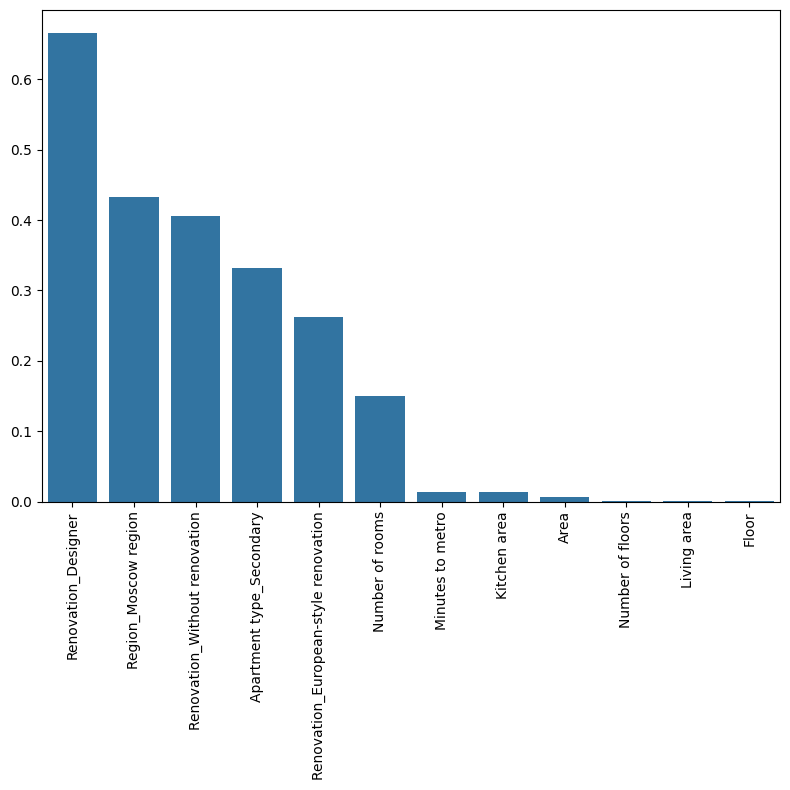

In [11]:
plt.figure(figsize=(8, 8))
sns.barplot(coef_df)
plt.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

### OLS Regression -- Findings

A standard OLS linear regression was fit on all 12 features to establish a baseline. The model
explained roughly 87% of the variation in log-transformed apartment prices on the held-out test
set (Test R² = 0.87), with almost no gap between training and test performance, which suggests
the model generalizes well without overfitting.

Renovation quality and location were the strongest price drivers in the coefficient analysis.
Designer renovations commanded a large premium, while apartments with no renovation were
significantly discounted. Being located within Moscow city versus the Moscow region also carried
a notable price bump. Continuous features like area and number of rooms did not appear in the
top five coefficients, but this does not mean they are unimportant. Their per-unit effects are
simply smaller in magnitude compared to the all-or-nothing jump captured by binary dummy variables.

The log-scale RMSE of 0.39 is the most reliable accuracy metric here, since ruble-denominated
error figures get distorted by a small number of high-value luxury listings. This baseline will
serve as the benchmark for all models going forward.

## **Lasso Model**

In [7]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [8]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_cols =  ['Minutes to metro', 'Number of rooms', 'Area', 
                'Living area', 'Kitchen area', 'Floor', 'Number of floors']



preprocess = ColumnTransformer(
    transformers= [
        ('num', numeric_transformer, numeric_cols)
    ],
    remainder='passthrough'
)

X_train_p = preprocess.fit_transform(X_train)
X_test_p = preprocess.transform(X_test)

display(X_train_p[1], X_train.iloc[1])

array([-0.12848837, -0.11938385, -0.4097516 , -0.29426583, -0.92361638,
        0.86040309,  0.27895916,  0.        ,  1.        ,  0.        ,
        0.        ,  0.        ])

Minutes to metro                        11.00
Number of rooms                          2.00
Area                                    46.36
Living area                             28.50
Kitchen area                             5.40
Floor                                   15.00
Number of floors                        20.00
Apartment type_Secondary                 0.00
Region_Moscow region                     1.00
Renovation_Designer                      0.00
Renovation_European-style renovation     0.00
Renovation_Without renovation            0.00
Name: 18291, dtype: float64

In [9]:
lasso_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('lasso', LassoCV(
        cv = 10,
        random_state=42,
        max_iter=10000
    ))
])

lasso_pipeline.fit(X_train, y_train)

y_pred_lasso_train = lasso_pipeline.predict(X_train)
y_pred_lasso_test = lasso_pipeline.predict(X_test)

# Metrics
lasso_train_r2 = r2_score(y_train, y_pred_lasso_train)
lasso_test_r2 = r2_score(y_test, y_pred_lasso_test)
lasso_rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_lasso_test))
lasso_mae_rub  = mean_absolute_error(np.exp(y_test), np.exp(y_pred_lasso_test))

best_alpha = lasso_pipeline.named_steps['lasso'].alpha_
lasso_coefs = lasso_pipeline.named_steps['lasso'].coef_
n_zeroed = np.sum(lasso_coefs == 0)
n_kept = np.sum(lasso_coefs != 0)

print("=== Lasso Regression ===")
print(f"Best alpha:      {best_alpha:.6f}")
print(f"Features kept:   {n_kept} / {X_train.shape[1]}")
print(f"Features zeroed: {n_zeroed}")
print(f"Train R²:        {lasso_train_r2:.4f}")
print(f"Test R²:         {lasso_test_r2:.4f}")
print(f"RMSE (log):      {lasso_rmse_log:.4f}")
print(f"MAE (₽):         {lasso_mae_rub:,.0f}")

coef_series = pd.Series(lasso_coefs, index=X.columns)
print("\nZeroed out features:")
print(coef_series[coef_series == 0].index.tolist())
print("\nKept features (by |coefficient|):")
print(coef_series[coef_series != 0].abs().sort_values(ascending=False))

=== Lasso Regression ===
Best alpha:      0.000852
Features kept:   11 / 12
Features zeroed: 1
Train R²:        0.8599
Test R²:         0.8694
RMSE (log):      0.3889
MAE (₽):         26,833,143

Zeroed out features:
['Floor']

Kept features (by |coefficient|):
Renovation_Designer                     0.647620
Region_Moscow region                    0.432241
Area                                    0.396803
Renovation_Without renovation           0.388005
Apartment type_Secondary                0.338869
Renovation_European-style renovation    0.247459
Number of rooms                         0.220170
Kitchen area                            0.110633
Minutes to metro                        0.088055
Living area                             0.020605
Number of floors                        0.011610
dtype: float64


## Lasso Regression -- Findings

Lasso regression was fit using 10-fold cross-validation to automatically select the best
regularization strength. Out of the 12 features, only one was zeroed out: Floor. This lines
up with what the EDA already suggested: floor number had almost no correlation with price
(0.11) and turns out not to be a meaningful predictor once everything else is accounted for.

The fact that Lasso kept 11 out of 12 features tells us the original feature set was already
fairly lean. There was no junk to trim. Notably, both Area and Living area were kept despite
their high collinearity (0.91), though Lasso pushed Living area's coefficient down to nearly
zero (0.02 vs 0.40 for Area) -- effectively signaling that Area is the dominant size predictor
and Living area adds little on top of it.

Performance was essentially identical to the OLS baseline (Test R² = 0.87, RMSE log = 0.39),
which is expected when there are no noisy features to penalize away. The value of Lasso here
is less about accuracy gains and more about confirming which features actually matter -- and
pointing us toward a cleaner feature set for the statsmodels interpretation step coming up.
